Files ready on the local disk

 Start Training ResNet Standard...
Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 177s 355ms/step - accuracy: 0.7518 - auc: 0.8263 - loss: 0.8787 - val_accuracy: 0.6586 - val_auc: 0.7213 - val_loss: 1.6130 - learning_rate: 1.0000e-04
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 91s 182ms/step - accuracy: 0.7946 - auc: 0.8731 - loss: 0.7768 - val_accuracy: 0.7465 - val_auc: 0.8957 - val_loss: 0.8605 - learning_rate: 1.0000e-04
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 177ms/step - accuracy: 0.8159 - auc: 0.8952 - loss: 0.7068 - val_accuracy: 0.7926 - val_auc: 0.9153 - val_loss: 0.7194 - learning_rate: 1.0000e-04
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 179ms/step - accuracy: 0.8355 - auc: 0.9139 - loss: 0.6405 - val_accuracy: 0.8234 - val_auc: 0.9094 - val_loss: 0.6608 - learning_rate: 1.0000e-04
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.8518 - auc: 0.9271 - loss: 0.5849 - val_accuracy: 0.8330 - val_auc: 0.9269 - val_loss: 0.6203 - lear

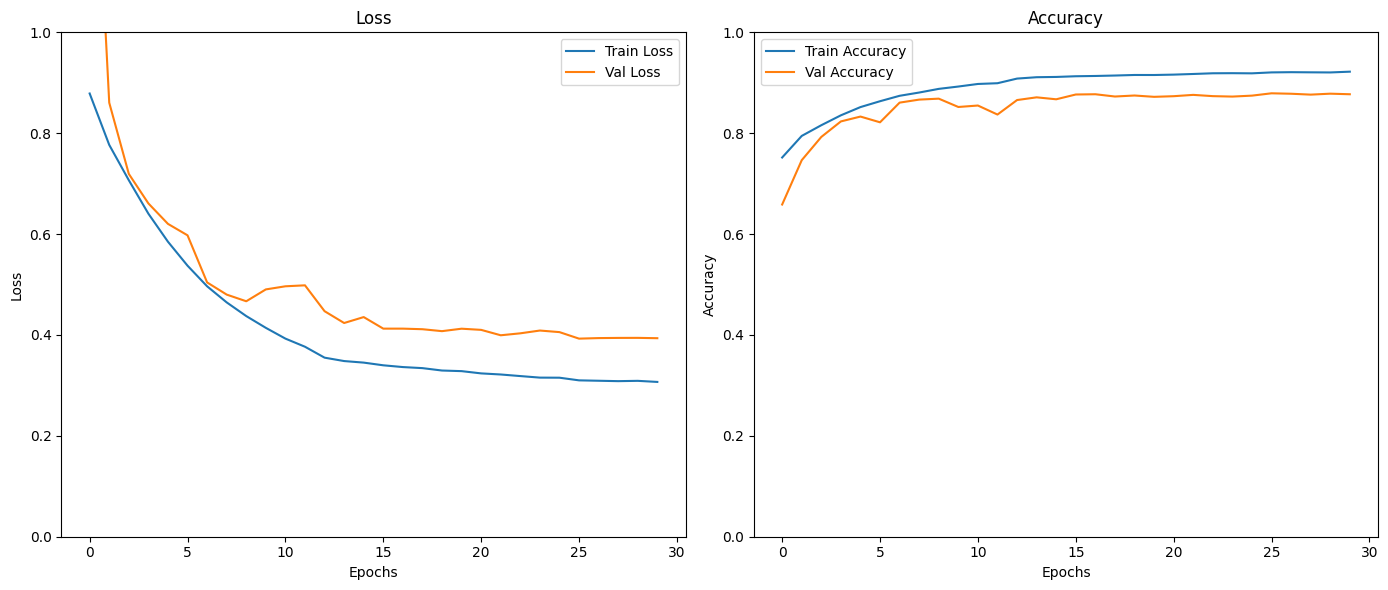


 Final evaluation on test set...
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step
              precision    recall  f1-score   support

     Healthy       0.86      0.83      0.85     16391
       Tumor       0.84      0.87      0.85     16377

    accuracy                           0.85     32768
   macro avg       0.85      0.85      0.85     32768
weighted avg       0.85      0.85      0.85     32768



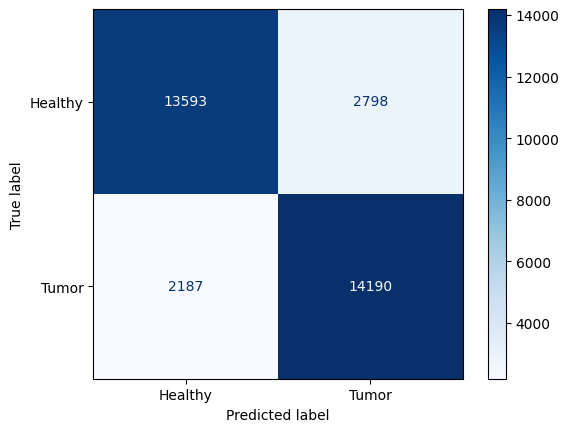

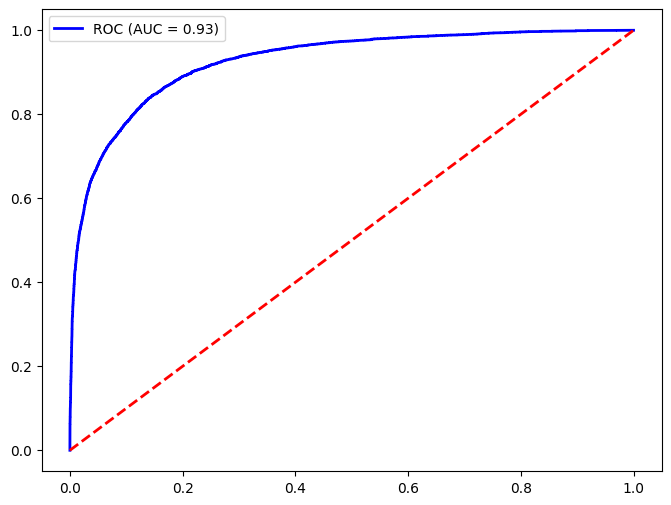

In [ ]:
from google.colab import drive
import os
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from tqdm import tqdm

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# --- 1. PREPARAZIONE FILE ---
!rm -rf /content/*.h5
for f in ['train_x','train_y','valid_x','valid_y','test_x','test_y']:
    src = f"/content/drive/MyDrive/PCam/camelyonpatch_level_2_split_{f}.h5"
    if os.path.exists(src):
        !cp "$src" /content/
print("Files ready on the local disk")

np.random.seed(42)
tf.random.set_seed(42)

# --- 2. CARICAMENTO DATI ---
def load_to_ram(x_path, y_path, num_samples=80000):
    with h5py.File(y_path, 'r') as fy:
        y_all = fy['y'][:num_samples].reshape(-1, 1).astype('float32')
    with h5py.File(x_path, 'r') as fx:
        x_all = fx['x'][:num_samples]
    return x_all, y_all

X_train, Y_train = load_to_ram('/content/camelyonpatch_level_2_split_train_x.h5',
                                    '/content/camelyonpatch_level_2_split_train_y.h5', 80000)
X_val, Y_val = load_to_ram('/content/camelyonpatch_level_2_split_valid_x.h5',
                                    '/content/camelyonpatch_level_2_split_valid_y.h5', 8000)

# --- 3. DATA AUGMENTATION SU CPU (Mantenuta identica alla G-CNN) ---
def augment(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.15)
    image = tf.image.random_contrast(image, 0.85, 1.15)
    return image, label

def process_val(image, label):
    image = tf.image.resize_with_crop_or_pad(image, 80, 80)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# --- 4. ARCHITETTURA RESNET STANDARD ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')
l2_val = 5e-4

def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', kernel_regularizer=regularizers.l2(l2_val))(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    return layers.Activation('relu')(layers.Add()([x, shortcut]))

def build_resnet_standard():
    inputs = layers.Input(shape=(80, 80, 3))

    # Sostituito Lifting Layer con Conv2D standard
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)

    # Blocchi Residui (Stessa struttura della G-CNN)
    for f in [64, 128, 256]:
        x = residual_block(x, f)
        x = layers.MaxPooling2D()(x)
        x = layers.SpatialDropout2D(0.2)(x)

    # RIMOSSO GroupPool() - Qui finisce la logica ResNet standard
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)
    return models.Model(inputs, outputs)

model = build_resnet_standard()
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')], jit_compile=True)

# --- 5. TRAINING PHASE ---
BATCH_SIZE = 256

train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))\
    .shuffle(10000).map(augment, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))\
    .map(process_val, num_parallel_calls=tf.data.AUTOTUNE)\
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"\n Start Training ResNet Standard...")
history = model.fit(train_ds, validation_data=val_ds, epochs=30,
                    callbacks=[callbacks.EarlyStopping(patience=10, restore_best_weights=True),
                               callbacks.ReduceLROnPlateau(factor=0.2, patience=3, verbose=1)])

# Saving the model
model.save('/content/drive/MyDrive/resnet_standard_model.keras')

# --- 6. GRAFICI ---
# PLOT OF FIGURES
plt.figure(figsize=(14,6))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss"); plt.xlabel("Epochs"); plt.ylabel("Loss")
plt.ylim(0, 1.0); plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy"); plt.xlabel("Epochs"); plt.ylabel("Accuracy")
plt.ylim(0, 1.0); plt.legend()

plt.tight_layout()
plt.show()

# --- 7. VALUTAZIONE ---
print("\n Final evaluation on test set...")
with h5py.File('/content/camelyonpatch_level_2_split_test_x.h5','r') as fx, \
     h5py.File('/content/camelyonpatch_level_2_split_test_y.h5','r') as fy:
    X_test, Y_test = fx['x'][:], fy['y'][:].reshape(-1,1).astype('float32')

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test))\
    .map(process_val).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

y_pred_prob = model.predict(test_ds)
y_pred = (y_pred_prob > 0.35).astype(int)

print(classification_report(Y_test, y_pred, target_names=["Healthy","Tumor"]))

cm = confusion_matrix(Y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Healthy","Tumor"])
disp.plot(cmap='Blues', values_format='d'); plt.show()

fpr, tpr, _ = roc_curve(Y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8,6)); plt.plot(fpr, tpr, color="blue", lw=2, label="ROC (AUC = %0.2f)" % roc_auc); plt.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--"); plt.legend(); plt.show()